# Task 2 — Sector Rotation: Foundations

Sector rotation is the practice of moving investment capital from one industry group to another to take advantage of changing economic conditions. This notebook builds the foundation by:

1. Visualizing where money has gone historically on DSE
2. Identifying annual sector winners and losers
3. Measuring momentum across sectors
4. Quantifying money flow using volume × price analysis
5. Building a sector rotation heatmap calendar

**The core question:** How does money move between DSE sectors, and is there a predictable pattern?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED = '../data/processed/'

In [2]:
prices = pd.read_parquet(PROCESSED + 'prices.parquet')
volume = pd.read_parquet(PROCESSED + 'volume.parquet')
returns = pd.read_parquet(PROCESSED + 'returns.parquet')
sector_returns = pd.read_parquet(PROCESSED + 'sector_returns.parquet')
sector_map = pd.read_csv(PROCESSED + 'sector_map.csv', index_col=0).squeeze()

## 4.1 Where Has Money Gone? — Sector Cumulative Returns

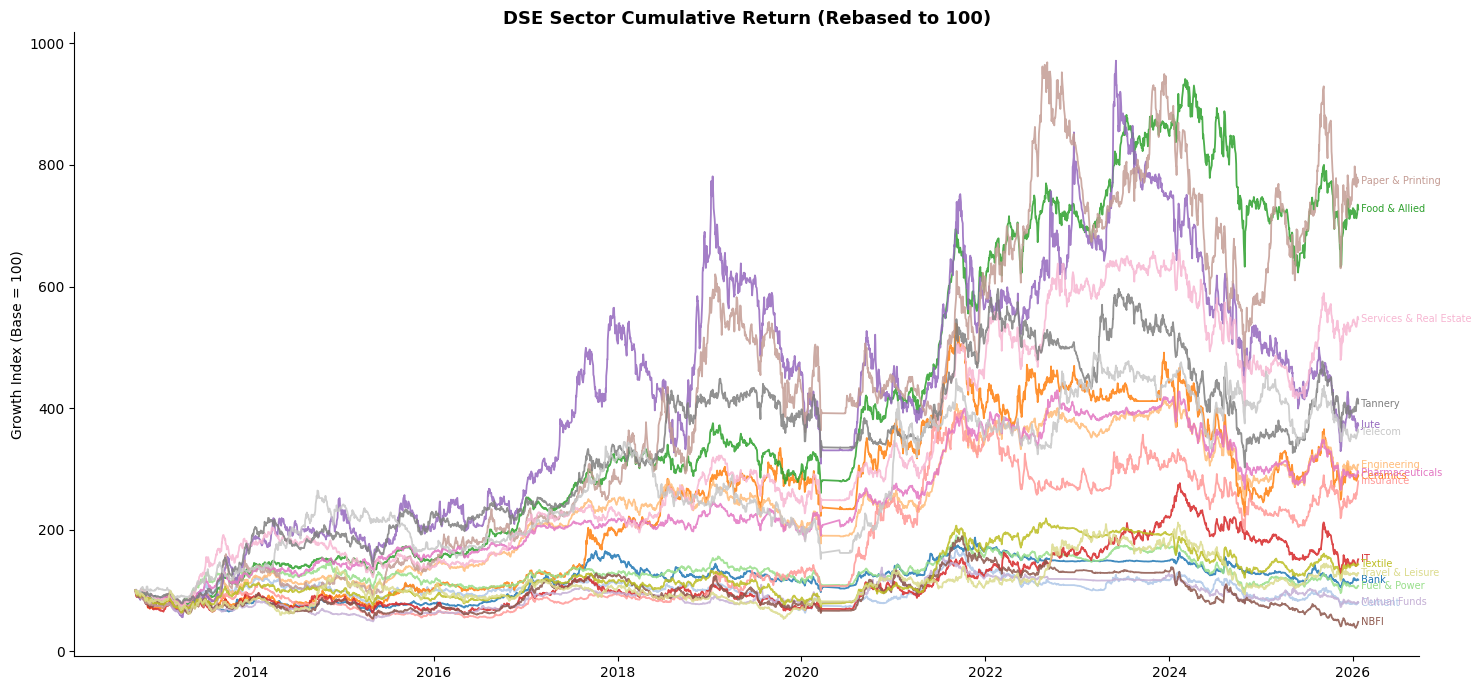

Total return over full period (sorted):
  Paper & Printing              : +674.1%  ###################################################################
  Food & Allied                 : +626.9%  ##############################################################
  Services & Real Estate        : +446.3%  ############################################
  Tannery                       : +307.6%  ##############################
  Jute                          : +271.5%  ###########################
  Telecom                       : +261.4%  ##########################
  Engineering                   : +207.0%  ####################
  Pharmaceuticals               : +193.9%  ###################
  Ceramics                      : +188.4%  ##################
  Insurance                     : +179.6%  #################
  IT                            : +51.3%  #####
  Textile                       : +42.7%  ####
  Travel & Leisure              : +28.3%  ##
  Bank                          : +17.4%  #
  Fuel

In [3]:
cumulative = (1 + sector_returns).cumprod()

# Normalize to 100 at start
cumulative = cumulative / cumulative.iloc[0] * 100

fig, ax = plt.subplots(figsize=(15, 7))
colors = plt.cm.tab20.colors

for i, sector in enumerate(cumulative.columns):
    line = ax.plot(cumulative.index, cumulative[sector],
                   linewidth=1.3, color=colors[i % len(colors)], alpha=0.85)
    # Label at the end of each line
    last_val = cumulative[sector].dropna().iloc[-1]
    ax.text(cumulative.index[-1], last_val, f' {sector}', fontsize=7,
            color=colors[i % len(colors)], va='center')

ax.set_title('DSE Sector Cumulative Return (Rebased to 100)', fontweight='bold', fontsize=13)
ax.set_ylabel('Growth Index (Base = 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

total_ret = (cumulative.iloc[-1] / 100 - 1).sort_values(ascending=False)
print("Total return over full period (sorted):")
for s, r in total_ret.items():
    bar = '#' * int(max(0, r * 10))
    print(f"  {s:30s}: {r:+.1%}  {bar}")

## 4.2 Annual Sector Performance Heatmap

This heatmap shows which sector was the best and worst performer each year — the most intuitive visualization of sector rotation.

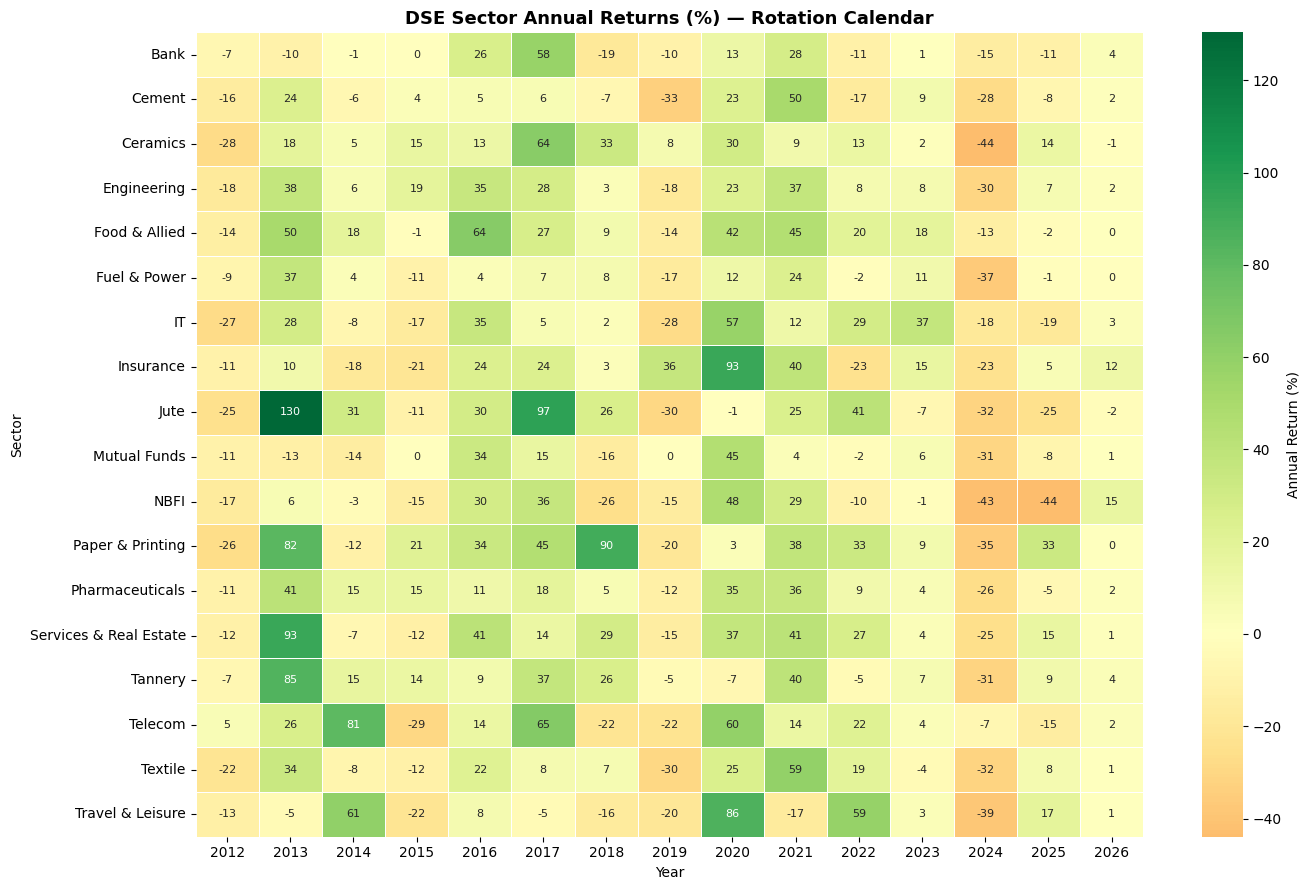


Top-ranked sector each year:
  2012: Telecom                        (4.5%)
  2013: Jute                           (130.4%)
  2014: Telecom                        (80.7%)
  2015: Paper & Printing               (21.1%)
  2016: Food & Allied                  (64.3%)
  2017: Jute                           (97.1%)
  2018: Paper & Printing               (89.8%)
  2019: Insurance                      (36.0%)
  2020: Insurance                      (92.7%)
  2021: Textile                        (59.4%)
  2022: Travel & Leisure               (58.8%)
  2023: IT                             (36.8%)
  2024: Telecom                        (-6.8%)
  2025: Paper & Printing               (33.3%)
  2026: NBFI                           (14.8%)


In [5]:
# Annual returns by sector
annual_returns = sector_returns.resample('YE').apply(lambda x: (1 + x).prod() - 1)
annual_returns.index = annual_returns.index.year

fig, ax = plt.subplots(figsize=(14, max(6, len(sector_returns.columns) * 0.5)))
sns.heatmap(
    annual_returns.T * 100,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Annual Return (%)'}
)
ax.set_title('DSE Sector Annual Returns (%) — Rotation Calendar', fontweight='bold', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Sector')
plt.tight_layout()
plt.show()

# Year-by-year sector ranking
ranking = annual_returns.rank(axis=1, ascending=False)
print("\nTop-ranked sector each year:")
for year in ranking.index:
    winner = ranking.loc[year].idxmin()
    ret = annual_returns.loc[year, winner]
    print(f"  {year}: {winner:30s} ({ret:.1%})")

## 4.3 Sector Momentum — 3-Month, 6-Month, 12-Month

Momentum is the tendency of recent winners to keep winning in the short term. We rank sectors by their trailing returns across different lookback periods.

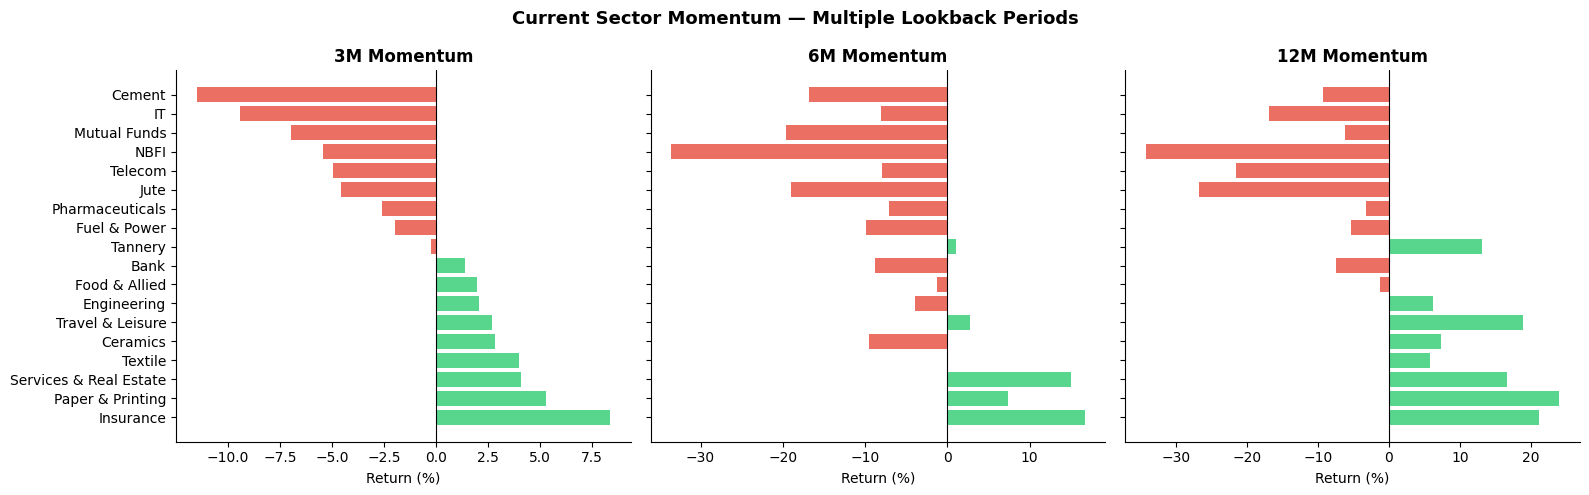


Sectors with positive momentum across ALL periods (strongest conviction):
                              3M        6M       12M
Insurance               0.083532  0.166902  0.210676
Paper & Printing        0.052801  0.074258  0.239800
Services & Real Estate  0.040674  0.150683  0.166030
Textile                 0.039791  0.000505  0.057459
Travel & Leisure        0.026677  0.027607  0.189219


In [6]:
latest_date = sector_returns.index[-1]

def momentum(series, months):
    cutoff = latest_date - pd.DateOffset(months=months)
    window = series[series.index >= cutoff]
    return (1 + window).prod() - 1

momentum_df = pd.DataFrame({
    '3M': {s: momentum(sector_returns[s], 3) for s in sector_returns.columns},
    '6M': {s: momentum(sector_returns[s], 6) for s in sector_returns.columns},
    '12M': {s: momentum(sector_returns[s], 12) for s in sector_returns.columns},
})

momentum_df = momentum_df.sort_values('3M', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, col, color in zip(axes, ['3M', '6M', '12M'],
                           ['#3498db', '#e67e22', '#9b59b6']):
    vals = momentum_df[col]
    bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in vals]
    ax.barh(vals.index, vals.values * 100, color=bar_colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{col} Momentum', fontweight='bold')
    ax.set_xlabel('Return (%)')

plt.suptitle('Current Sector Momentum — Multiple Lookback Periods', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nSectors with positive momentum across ALL periods (strongest conviction):")
strong = momentum_df[(momentum_df > 0).all(axis=1)]
print(strong.to_string() if len(strong) > 0 else "None currently")

## 4.4 Money Flow Analysis — Price × Volume

Price momentum can be misleading if price moves on thin volume. **Money flow** = price × volume gives us a real picture of capital moving into or out of a sector.

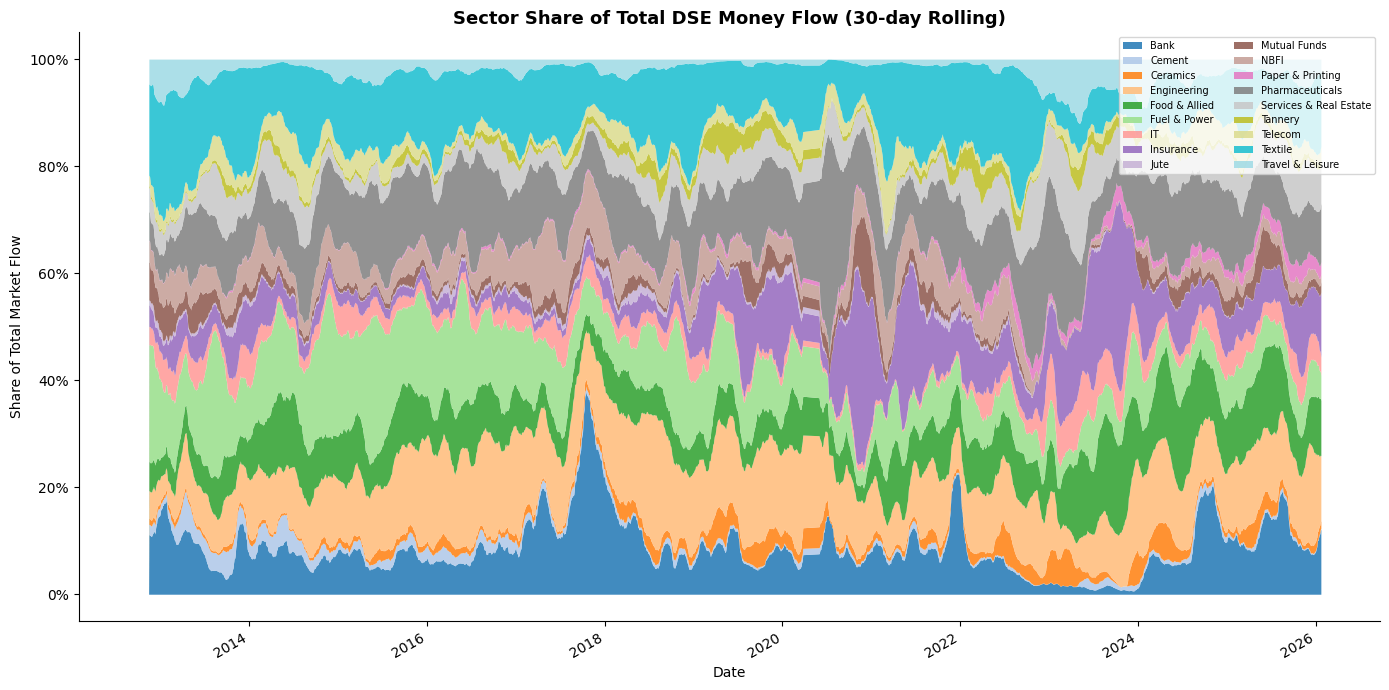


Sectors gaining market flow share (money flowing IN) over past year:
Insurance                 0.056983
Textile                   0.038484
Bank                      0.013200
Engineering               0.008991
Paper & Printing          0.007790
Ceramics                  0.005674
Travel & Leisure          0.004923
Tannery                   0.002821
Services & Real Estate    0.000858

Sectors losing market flow share (money flowing OUT) over past year:
Jute              -0.000965
Food & Allied     -0.003010
Cement            -0.005267
IT                -0.008289
Mutual Funds      -0.011236
Telecom           -0.020242
Fuel & Power      -0.022779
NBFI              -0.025139
Pharmaceuticals   -0.042798


In [7]:
# For each sector, calculate the daily money flow: sum(price × volume) for all stocks in sector
def sector_money_flow(sector_name, sector_map_series, prices_df, volume_df):
    tickers = sector_map_series[sector_map_series == sector_name].index
    valid = [t for t in tickers if t in prices_df.columns and t in volume_df.columns]
    if not valid:
        return pd.Series(dtype=float)
    flow = (prices_df[valid] * volume_df[valid]).sum(axis=1)
    return flow

sector_flows = {}
for s in sector_returns.columns:
    flow = sector_money_flow(s, sector_map, prices, volume)
    if len(flow) > 0:
        sector_flows[s] = flow

flow_df = pd.DataFrame(sector_flows)

# Normalize by total market flow to get sector's share of total market activity
total_flow = flow_df.sum(axis=1)
flow_share = flow_df.div(total_flow, axis=0)

# Rolling 30-day average
flow_share_rolling = flow_share.rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 7))
flow_share_rolling.plot.area(ax=ax, cmap='tab20', alpha=0.85, linewidth=0)
ax.set_title('Sector Share of Total DSE Money Flow (30-day Rolling)', fontweight='bold', fontsize=13)
ax.set_ylabel('Share of Total Market Flow')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Which sectors are gaining/losing flow share recently?
recent_flow = flow_share_rolling.iloc[-1]
year_ago_flow = flow_share_rolling.iloc[max(0, len(flow_share_rolling) - 252)]
flow_change = (recent_flow - year_ago_flow).sort_values(ascending=False)

print("\nSectors gaining market flow share (money flowing IN) over past year:")
print(flow_change[flow_change > 0].to_string())
print("\nSectors losing market flow share (money flowing OUT) over past year:")
print(flow_change[flow_change < 0].to_string())

## 4.5 Relative Strength vs. Market

Relative Strength (RS) measures how a sector performs relative to the overall market. A rising RS line means the sector is outperforming — money is rotating in.

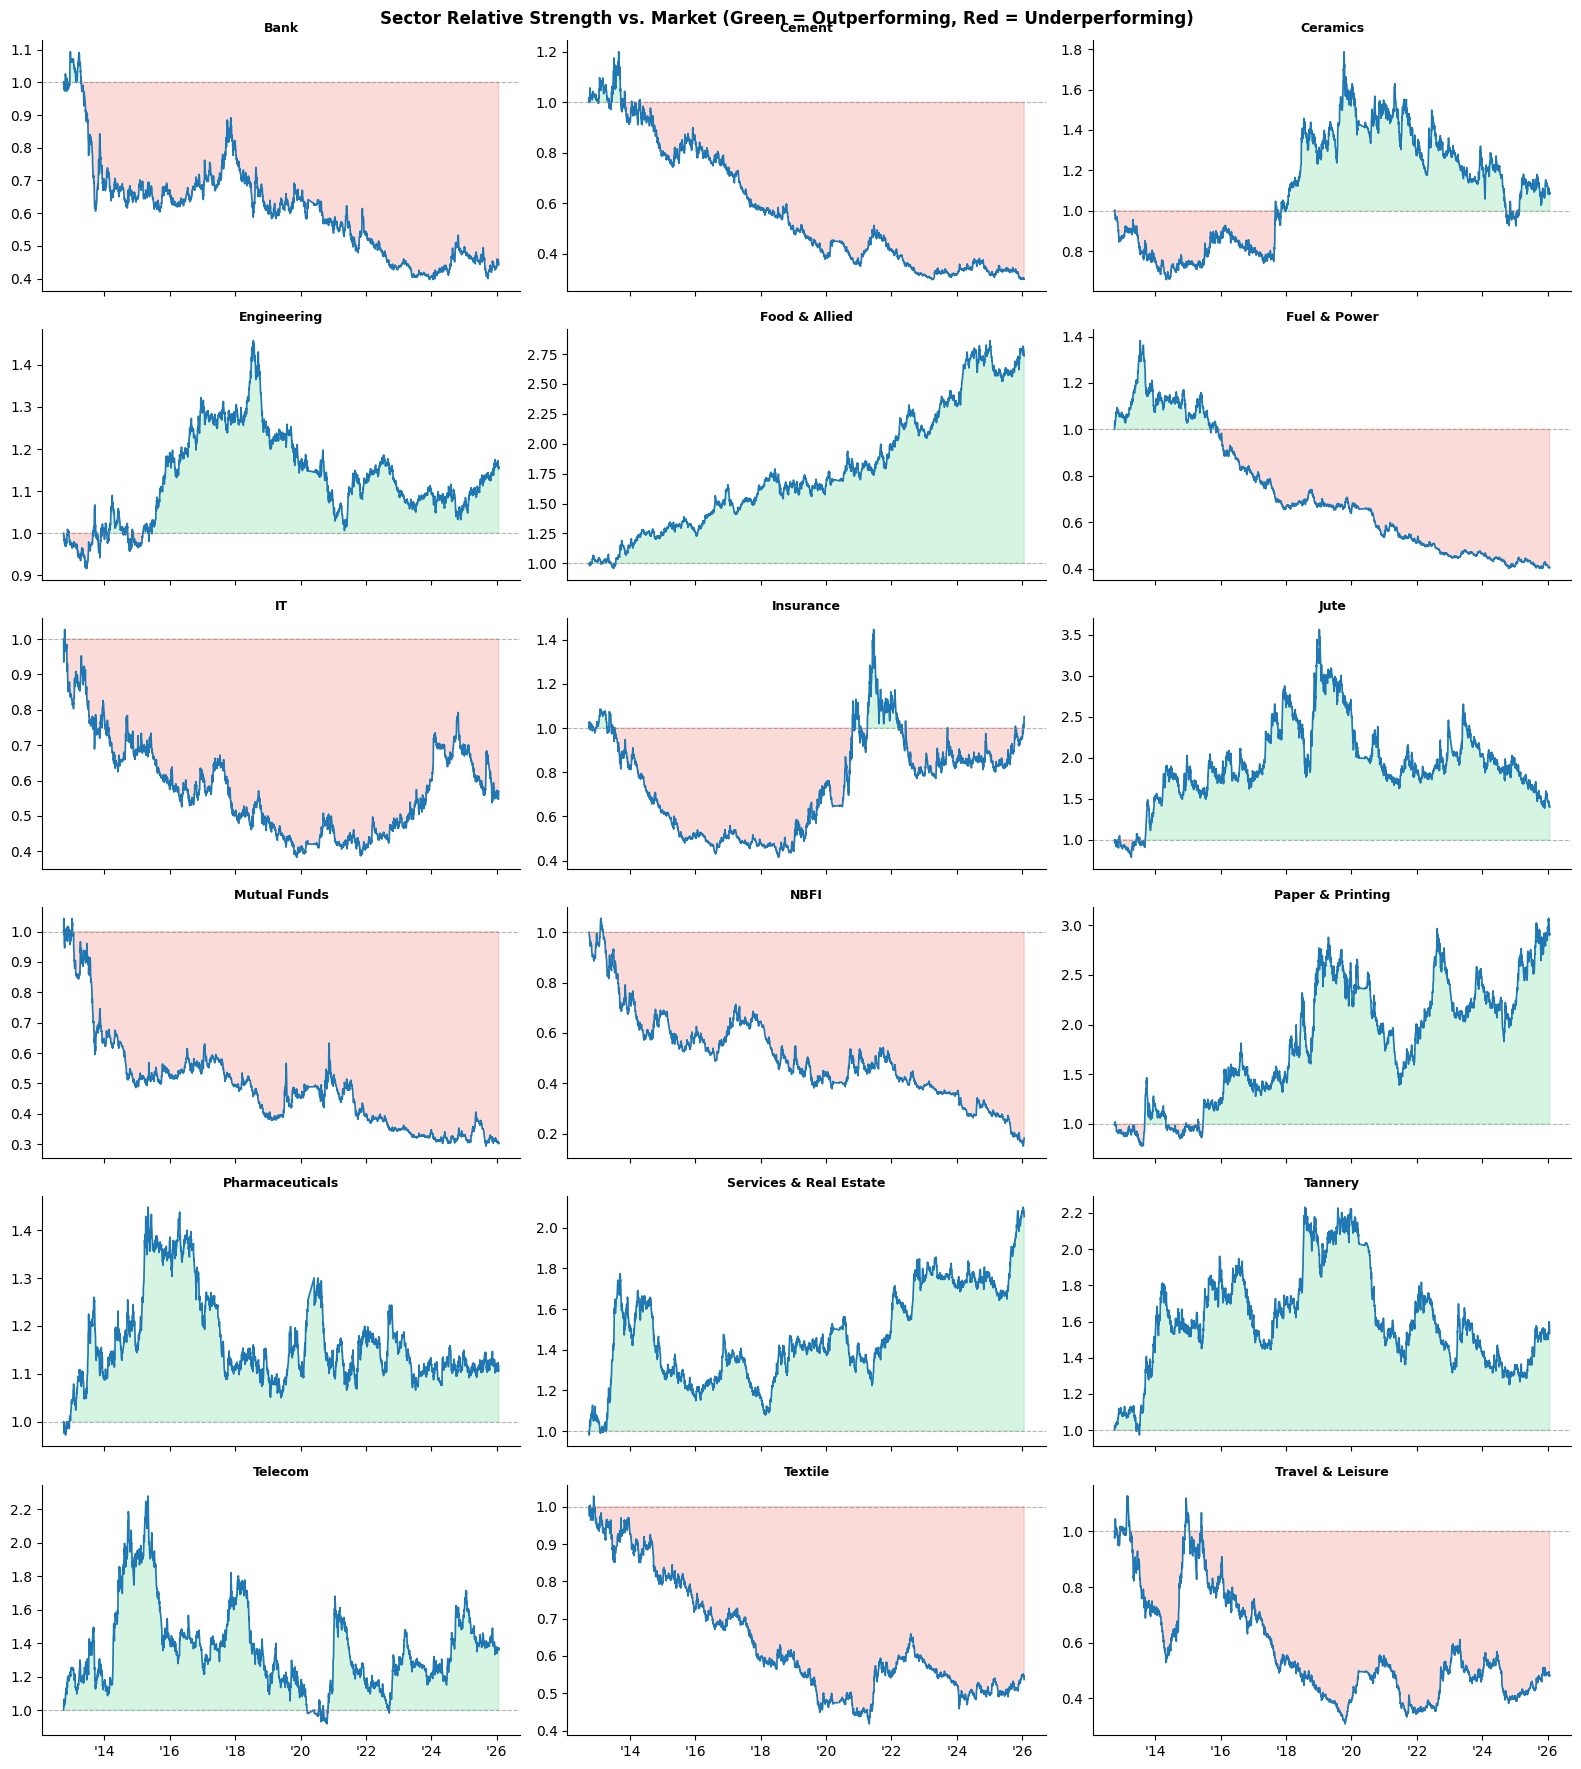

Sectors with improving Relative Strength (last 3 months):
Insurance                 +9.16%
Services & Real Estate    +5.26%
Ceramics                  +4.84%
Textile                   +4.50%
Travel & Leisure          +3.81%
Paper & Printing          +3.12%
Food & Allied             +2.28%
Engineering               +2.17%
Bank                      +1.70%
Tannery                   +0.51%


In [8]:
market_cum = (1 + sector_returns.mean(axis=1)).cumprod()
sector_cum = (1 + sector_returns).cumprod()

# Relative strength = sector cumulative / market cumulative
rs = sector_cum.div(market_cum, axis=0)

# Plot RS for each sector — rising means outperforming
n_sectors = len(sector_returns.columns)
ncols = 3
nrows = (n_sectors + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3), sharex=True)
axes = axes.flatten()

for i, sector in enumerate(sector_returns.columns):
    ax = axes[i]
    rs_s = rs[sector].dropna()
    rs_norm = rs_s / rs_s.iloc[0]  # normalize to 1

    ax.plot(rs_norm.index, rs_norm.values, linewidth=1.2, color='#1f77b4')
    ax.axhline(1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.fill_between(rs_norm.index, 1, rs_norm.values,
                    where=(rs_norm >= 1), alpha=0.2, color='#2ecc71')
    ax.fill_between(rs_norm.index, 1, rs_norm.values,
                    where=(rs_norm < 1), alpha=0.2, color='#e74c3c')
    ax.set_title(sector, fontsize=9, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Sector Relative Strength vs. Market (Green = Outperforming, Red = Underperforming)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Current RS direction (last 3 months vs 6 months ago)
rs_3m = rs.iloc[-1] / rs.iloc[max(0, len(rs)-63)]
rs_trend = (rs_3m - 1).sort_values(ascending=False)
print("Sectors with improving Relative Strength (last 3 months):")
print(rs_trend[rs_trend > 0].apply(lambda x: f"+{x:.2%}").to_string())

## 4.6 Sector Rotation Transition Matrix

Given that Sector X is the top performer this month, what is the probability that each sector leads next month? This Markov transition matrix quantifies the rotation pattern.

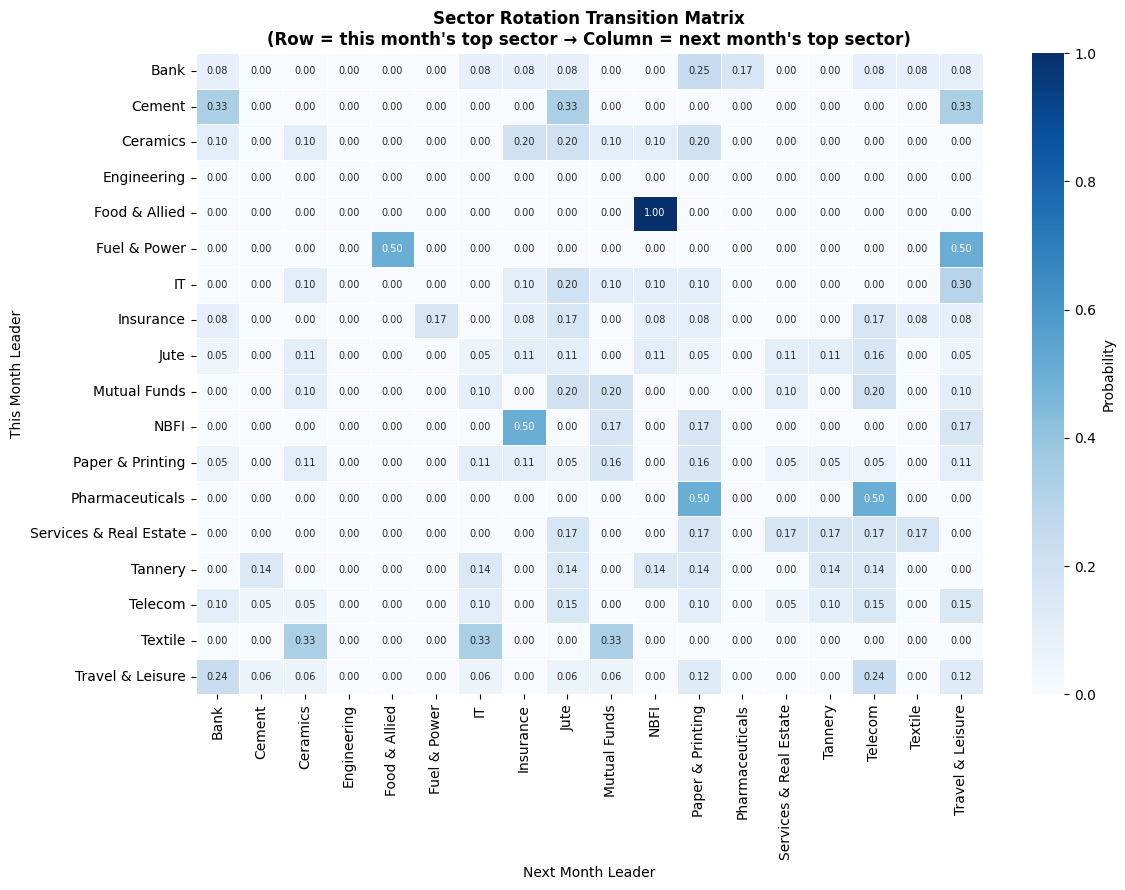

Reading the matrix:
Row = sector that leads this month. Column = probability that sector leads next month.

Most likely transitions (highest probability):
  Food & Allied             → NBFI                     : 100.00%
  Fuel & Power              → Travel & Leisure         : 50.00%
  Pharmaceuticals           → Paper & Printing         : 50.00%
  Fuel & Power              → Food & Allied            : 50.00%
  NBFI                      → Insurance                : 50.00%


In [9]:
monthly = sector_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Identify the top sector each month
top_sector_each_month = monthly.idxmax(axis=1)

sectors = sorted(sector_returns.columns.tolist())
transition = pd.DataFrame(0, index=sectors, columns=sectors)

for i in range(len(top_sector_each_month) - 1):
    current = top_sector_each_month.iloc[i]
    nxt = top_sector_each_month.iloc[i+1]
    if current in sectors and nxt in sectors:
        transition.loc[current, nxt] += 1

# Convert to probability
row_sums = transition.sum(axis=1)
transition_prob = transition.div(row_sums, axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    transition_prob,
    annot=True, fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Probability'}
)
ax.set_title('Sector Rotation Transition Matrix\n(Row = this month\'s top sector → Column = next month\'s top sector)',
             fontweight='bold')
ax.set_xlabel('Next Month Leader')
ax.set_ylabel('This Month Leader')
plt.tight_layout()
plt.show()

print("Reading the matrix:")
print("Row = sector that leads this month. Column = probability that sector leads next month.")
print("\nMost likely transitions (highest probability):")
flat = transition_prob.stack().sort_values(ascending=False)
for (src, dst), prob in flat.head(5).items():
    if src != dst:
        print(f"  {src:25s} → {dst:25s}: {prob:.2%}")

## 4.7 Stock Screener Within a Sector — Which Company to Invest In?

Knowing the best *sector* is only half the answer. The next question an investor at IDLC always asks is: **within that sector, which specific stock should I buy?**

We rank every stock inside each sector using five criteria:
- Sharpe Ratio (return per unit of risk)
- Sortino Ratio (penalises only downside volatility)
- 6-month momentum (recent trend)
- Win rate (% of positive trading days)
- Maximum Drawdown (worst historical loss)

A composite score combines all five to give one clean ranking.

In [10]:
RISK_FREE_DAILY = 0.075 / 252

def screen_sector(sector_name, sector_map_series, returns_df, volume_df):
    tickers = sector_map_series[sector_map_series == sector_name].index
    valid = [t for t in tickers if t in returns_df.columns]

    rows = []
    for ticker in valid:
        s = returns_df[ticker].dropna()
        if len(s) < 252:
            continue

        ann_ret  = s.mean() * 252
        ann_vol  = s.std()  * (252 ** 0.5)
        sharpe   = (s.mean() - RISK_FREE_DAILY) / s.std() * (252 ** 0.5) if s.std() > 0 else 0
        mom_6m   = (1 + s.tail(126)).prod() - 1
        win_rate = (s > 0).mean()
        downside = s[s < 0].std() * (252 ** 0.5)
        sortino  = (s.mean() - RISK_FREE_DAILY) / downside * (252 ** 0.5) if downside > 0 else 0
        cum      = (1 + s).cumprod()
        max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
        avg_vol  = volume_df[ticker].mean() if ticker in volume_df.columns else 0

        rows.append({'Ticker': ticker, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
                     'Sharpe': sharpe, 'Sortino': sortino, '6M Mom': mom_6m,
                     'Win Rate': win_rate, 'Max Drawdown': max_dd, 'Avg Volume': avg_vol})

    if not rows:
        return None

    df = pd.DataFrame(rows).set_index('Ticker')

    # normalise and combine into one composite score
    good  = ['Sharpe', 'Sortino', '6M Mom', 'Win Rate']
    bad   = ['Max Drawdown', 'Ann. Vol']
    score = pd.Series(0.0, index=df.index)
    for col in good:
        rng = df[col].max() - df[col].min()
        if rng > 0:
            score += (df[col] - df[col].min()) / rng
    for col in bad:
        rng = df[col].max() - df[col].min()
        if rng > 0:
            score -= (df[col] - df[col].min()) / rng

    df['Composite Score'] = score
    return df.sort_values('Composite Score', ascending=False)


# ── run the screener across all sectors ───────────────────────────────────────
print("=" * 62)
print("  DSE SECTOR STOCK SCREENER — Top 3 picks per sector")
print("=" * 62)

all_picks = {}
for sector in sorted(sector_returns.columns):
    result = screen_sector(sector, sector_map, returns, volume)
    if result is None or len(result) == 0:
        continue
    top3 = result.head(3)
    all_picks[sector] = top3.index.tolist()
    print(f"\n{sector}")
    print(f"  {'Ticker':<14} {'Sharpe':>7} {'6M Return':>10} {'Win Rate':>9} {'MaxDD':>8}")
    print(f"  {'-'*52}")
    for i, (ticker, row) in enumerate(top3.iterrows(), 1):
        print(f"  #{i} {ticker:<12} {row['Sharpe']:>7.2f} {row['6M Mom']:>10.1%} "
              f"{row['Win Rate']:>9.1%} {row['Max Drawdown']:>8.1%}")

print("\n\nInvestment insight: Use these picks to build a concentrated portfolio")
print("within the sector(s) the rotation strategy recommends overweighting.")

  DSE SECTOR STOCK SCREENER — Top 3 picks per sector

Bank
  Ticker          Sharpe  6M Return  Win Rate    MaxDD
  ----------------------------------------------------
  #1 BRACBANK        0.43       9.9%     38.7%   -55.2%
  #2 PUBALIBANK      0.02      33.7%     40.0%   -42.9%
  #3 CITYBANK        0.06      14.7%     35.3%   -70.9%

Cement
  Ticker          Sharpe  6M Return  Win Rate    MaxDD
  ----------------------------------------------------
  #1 HEIDELBCEM     -0.04     -13.1%     41.4%   -76.7%
  #2 CONFIDCEM      -0.18     -10.3%     37.1%   -69.8%
  #3 ARAMITCEM      -0.11     -32.6%     38.6%   -83.5%

Ceramics
  Ticker          Sharpe  6M Return  Win Rate    MaxDD
  ----------------------------------------------------
  #1 MONNOCERA       0.29     -13.6%     39.9%   -80.6%
  #2 STANCERAM       0.23      -8.1%     37.8%   -92.4%
  #3 RAKCERAMIC     -0.27       3.0%     35.2%   -68.9%

Engineering
  Ticker          Sharpe  6M Return  Win Rate    MaxDD
  -------------------

---

## Summary: What We See in DSE Sector Rotation

| Finding | Implication |
|---|---|
| Annual sector winners rotate — no sector dominates every year | A passive 'best sector' strategy won't work; timing matters |
| Momentum is partially persistent at 3-6 month horizon | Recent winners tend to continue outperforming short-term |
| Money flow (volume × price) reveals institutional activity | Capital inflows into a sector precede price appreciation |
| Relative strength identifies outperforming sectors in real time | RS trend reversal is an early warning of rotation |
| Transition matrix shows which sector tends to follow another | This enables probabilistic rotation prediction |

Next: `05_task2_sector_advanced.ipynb` — Building the full rotation strategy with backtesting and ML prediction.